In [ ]:
pip install qiskit qiskit-aer pylatexenc

#**Efficient_SU2**

The hardware efficient SU(2) 2-local circuit.

The EfficientSU2 circuit consists of layers of single qubit operations spanned by SU(2) and
C
X
CX entanglements. This is a heuristic pattern that can be used to prepare trial wave functions for variational quantum algorithms or classification circuit for machine learning.

SU(2) stands for special unitary group of degree 2, its elements are
2
×
2
2×2 unitary matrices with determinant 1, such as the Pauli rotation gates.

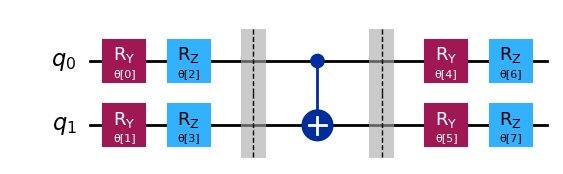

In [ ]:
from qiskit.circuit.library import efficient_su2

circ = efficient_su2(num_qubits=2, reps=1, insert_barriers=True)
circ.draw('mpl')

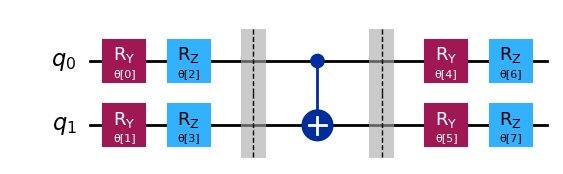

In [ ]:
circ = efficient_su2(num_qubits=2, reps=1, insert_barriers=True)
circ.draw('mpl')

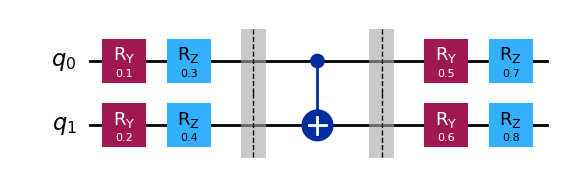

In [ ]:
x = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

encode = circ.assign_parameters(x)
encode.draw('mpl')

# ZFeatureMap in Qiskit

## Definition
ZFeatureMap is a quantum feature map used in Quantum Machine Learning (QML).

Purpose:
- Encode classical data into quantum states.
- Use phase encoding through Z-axis rotations.

It is commonly used in:
- Quantum Neural Networks (QNN)
- Quantum Support Vector Machines (QSVM)
- Variational Quantum Algorithms

---

# Main Idea

Given classical data:

$$
x = [x_1, x_2, x_3]
$$

ZFeatureMap converts these values into quantum phases.

---

# Why the Name "ZFeatureMap"?

Because it mainly uses rotations around the Z-axis:

$$
R_z(\theta)
$$

or phase gates:

$$
P(\theta)
$$

These gates modify the phase of the quantum state.

---

# Basic Structure

For each qubit:

1. Apply Hadamard gate:

$$
H
$$

2. Apply phase encoding:

$$
P(x_i)
\quad \text{or} \quad
R_z(x_i)
$$

---

# Basic Circuit

For two features:

$$
q_0 : H \rightarrow P(x_1)
$$

$$
q_1 : H \rightarrow P(x_2)
$$

---



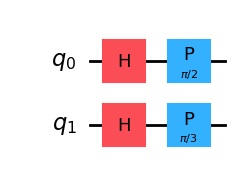

In [ ]:
from qiskit import QuantumCircuit
import numpy as np


qc0 = QuantumCircuit(1)
qc1 = QuantumCircuit(1)

qc0.h(0)
qc0.p(np.pi/2, 0)

qc1.h(0)
qc1.p(np.pi/3, 0)

qc = QuantumCircuit(2)
qc.compose(qc0, [0], inplace=True)
qc.compose(qc1, [1], inplace=True)

qc.draw('mpl', scale=1)

# ZZFeatureMap in Qiskit

## Definition

ZZFeatureMap is a quantum feature map used in Quantum Machine Learning (QML).

Purpose:
- Encode classical data into quantum states.
- Capture relationships between features using entanglement.

It extends the ZFeatureMap by adding:

$$
ZZ
$$

interactions between qubits.

---

# Main Idea

Given classical data:

$$
x = [x_1, x_2, x_3]
$$

ZZFeatureMap:
1. Encodes each feature into qubit phases.
2. Adds entanglement between qubits.
3. Encodes feature interactions.

---

# Why the Name "ZZ"?

Because it uses interactions based on Pauli-Z operators:

$$
Z \otimes Z
$$

called:

$$
ZZ \text{ interaction}
$$

This creates correlations between qubits.

---

# Basic Structure

Each layer contains:

1. Hadamard gates
2. Phase encoding
3. Entangling ZZ interactions

---

# Basic Circuit Flow

$$
H \rightarrow P(x_i) \rightarrow ZZ\text{-interaction}
$$

---

# Example Circuit (2 Qubits)

$$
q_0 : H \rightarrow P(x_1) \rightarrow \bullet
$$

$$
q_1 : H \rightarrow P(x_2) \rightarrow \bullet
$$

The two qubits become entangled.

---



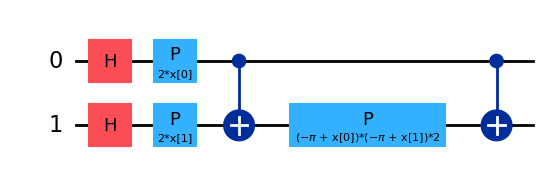

In [ ]:
from qiskit.circuit.library import zz_feature_map

feature_dim = 2

zzFP = zz_feature_map(feature_dimension=feature_dim, entanglement='linear', reps=1)

zzFP.draw('mpl')

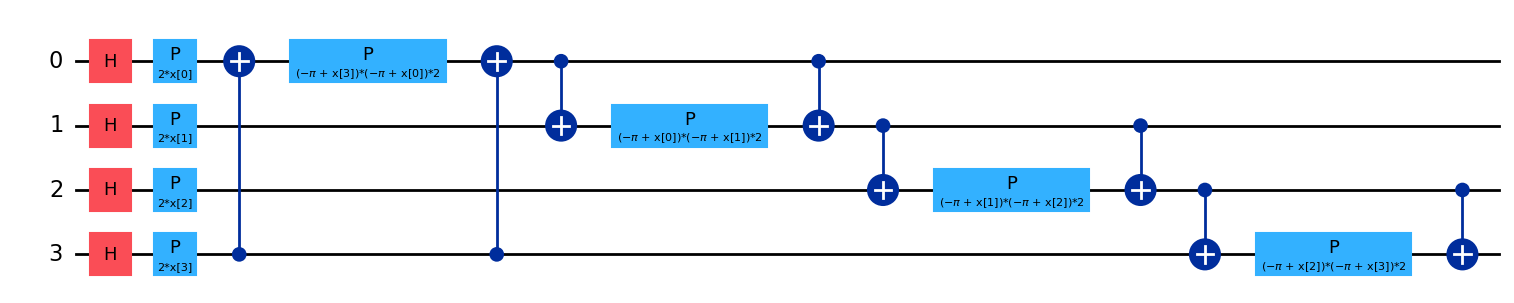

In [ ]:
from qiskit.circuit.library import zz_feature_map

feature_dim = 4

zzFP = zz_feature_map(feature_dimension=feature_dim, entanglement='circular', reps=1)

zzFP.draw('mpl')

# PauliFeatureMap in Qiskit

## Definition

PauliFeatureMap is a quantum feature map used in Quantum Machine Learning (QML).

Purpose:
- Encode classical data into quantum states.
- Use Pauli operators for feature encoding.
- Create expressive quantum embeddings.

It generalizes:
- ZFeatureMap
- ZZFeatureMap

by allowing different Pauli interactions.

---

# Main Idea

Given classical data:

$$
x = [x_1, x_2, x_3]
$$

PauliFeatureMap encodes data using Pauli operators such as:

$$
X, Y, Z
$$

and combinations like:

$$
ZZ, XX, YY
$$

---

# Pauli Operators

## Pauli-X

Acts like a quantum NOT gate.

$$
X =
\begin{bmatrix}
0 & 1 \\
1 & 0
\end{bmatrix}
$$

---

## Pauli-Y

Introduces rotation and phase.

$$
Y =
\begin{bmatrix}
0 & -i \\
i & 0
\end{bmatrix}
$$

---

## Pauli-Z

Changes phase.

$$
Z =
\begin{bmatrix}
1 & 0 \\
0 & -1
\end{bmatrix}
$$

---

# Why Use PauliFeatureMap?

It allows richer encoding than:
- ZFeatureMap
- ZZFeatureMap

because multiple quantum interactions can be used.

---

# General Encoding Form

The feature map approximately applies:

$$
U_{\phi}(x)
=
e^{i \phi(x) P}
$$

where:
- \(x\) = classical data
- \(P\) = Pauli operator

---

# Example Interactions

## Single-Qubit Encoding

$$
e^{i x Z}
$$

---

## Two-Qubit Interaction

$$
e^{i x_i x_j ZZ}
$$

---

## Other Possible Interactions

$$
XX,\ YY,\ ZX,\ XY
$$

---



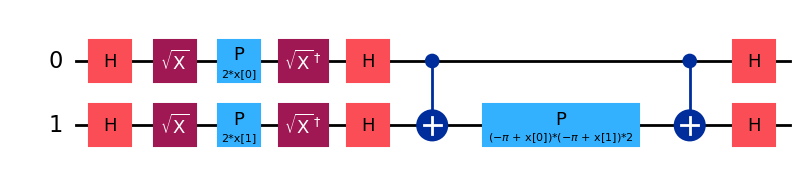

In [ ]:
from qiskit.circuit.library import pauli_feature_map

feature_dim = 2

PauliFP = pauli_feature_map(feature_dimension=feature_dim, reps=1, paulis=["Y", "XX"])

PauliFP.draw('mpl')

# TwoLocal in Qiskit

## Definition

TwoLocal is a parameterized quantum circuit (ansatz) in Qiskit.

Purpose:
- Build trainable quantum circuits.
- Create quantum states using:
  - single-qubit rotation layers
  - entanglement layers

It is widely used in:
- Variational Quantum Eigensolver (VQE)
- Quantum Machine Learning (QML)
- Hybrid quantum-classical algorithms

---

# Why the Name "TwoLocal"?

The term "TwoLocal" means:

- operations act locally on:
  - one qubit
  - or two qubits

It does not use large multi-qubit operations directly.

---

# Main Structure

A TwoLocal circuit consists of repeated blocks:

$$
\text{Rotation Layer}
\rightarrow
\text{Entanglement Layer}
\rightarrow
\text{Repeat}
$$

---

# Rotation Layer

Applies parameterized single-qubit gates.

Common rotation gates:

$$
R_x(\theta), \quad R_y(\theta), \quad R_z(\theta)
$$

These contain trainable parameters.

---

# Example Rotation Layer

For 3 qubits:

$$
q_0 : R_y(\theta_1)
$$

$$
q_1 : R_y(\theta_2)
$$

$$
q_2 : R_y(\theta_3)
$$

---

# Entanglement Layer

Connects qubits using two-qubit gates.

Common entangling gates:
- CX (CNOT)
- CZ
- CRX

Example:

$$
q_0 \rightarrow q_1
$$

using a CNOT gate.

---

# Basic Circuit Flow

$$
\text{Rotations}
\rightarrow
\text{Entanglement}
\rightarrow
\text{Rotations}
\rightarrow
\text{Entanglement}
$$

---


/tmp/ipykernel_3416/2981909945.py:3: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  twolocal = TwoLocal(num_qubits=5, reps=1, rotation_blocks=['ry','rz'], entanglement_blocks='cx', entanglement='linear', insert_barriers=True)


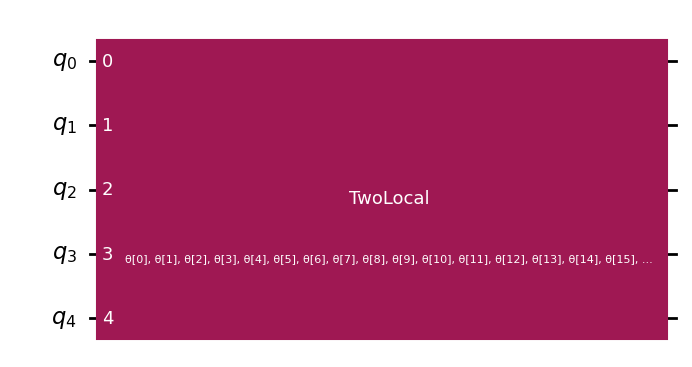

In [ ]:
from qiskit.circuit.library import TwoLocal

twolocal = TwoLocal(num_qubits=5, reps=1, rotation_blocks=['ry','rz'], entanglement_blocks='cx', entanglement='linear', insert_barriers=True)
twolocal.draw('mpl')

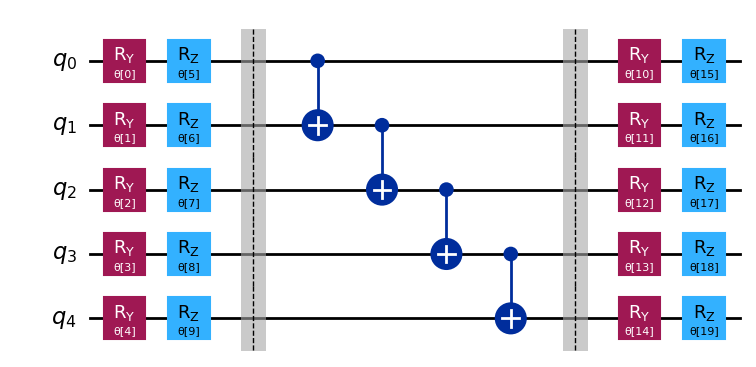

In [ ]:
twolocal.decompose().draw('mpl')

# NLocal in Qiskit

## Definition

NLocal is a general framework in Qiskit for building parameterized quantum circuits (ansätze).

Purpose:
- Create customizable variational circuits.
- Build trainable quantum states.
- Design flexible quantum circuit architectures.

It is commonly used in:
- Variational Quantum Eigensolver (VQE)
- Quantum Machine Learning (QML)
- Hybrid quantum-classical algorithms

---

# Why the Name "NLocal"?

The term "NLocal" means:

- operations can act on:
  - one qubit
  - two qubits
  - or larger local structures

"N" refers to:
- arbitrary numbers of qubits
- arbitrary local circuit blocks

---

# Hierarchy

$$
\text{NLocal}
\rightarrow
\text{TwoLocal}
\rightarrow
\text{EfficientSU2 / RealAmplitudes}
$$

Meaning:
- TwoLocal is built from NLocal.
- EfficientSU2 is built from TwoLocal.

---

# Main Structure

NLocal circuits are built using repeated layers:

$$
\text{Rotation Block}
\rightarrow
\text{Entanglement Block}
\rightarrow
\text{Repeat}
$$

---

# Rotation Blocks

These apply parameterized single-qubit gates.

Common gates:

$$
R_x(\theta), \quad R_y(\theta), \quad R_z(\theta)
$$

These gates contain trainable parameters.

---

# Example Rotation Layer

For 3 qubits:

$$
q_0 : R_y(\theta_1)
$$

$$
q_1 : R_y(\theta_2)
$$

$$
q_2 : R_y(\theta_3)
$$

---

# Entanglement Blocks

These connect qubits using multi-qubit gates.

Common gates:
- CX (CNOT)
- CZ
- CRX

Example:

$$
q_0 \rightarrow q_1
$$

using a CNOT gate.

---

# Basic Circuit Flow

$$
\text{Rotations}
\rightarrow
\text{Entanglement}
\rightarrow
\text{Rotations}
\rightarrow
\text{Entanglement}
$$



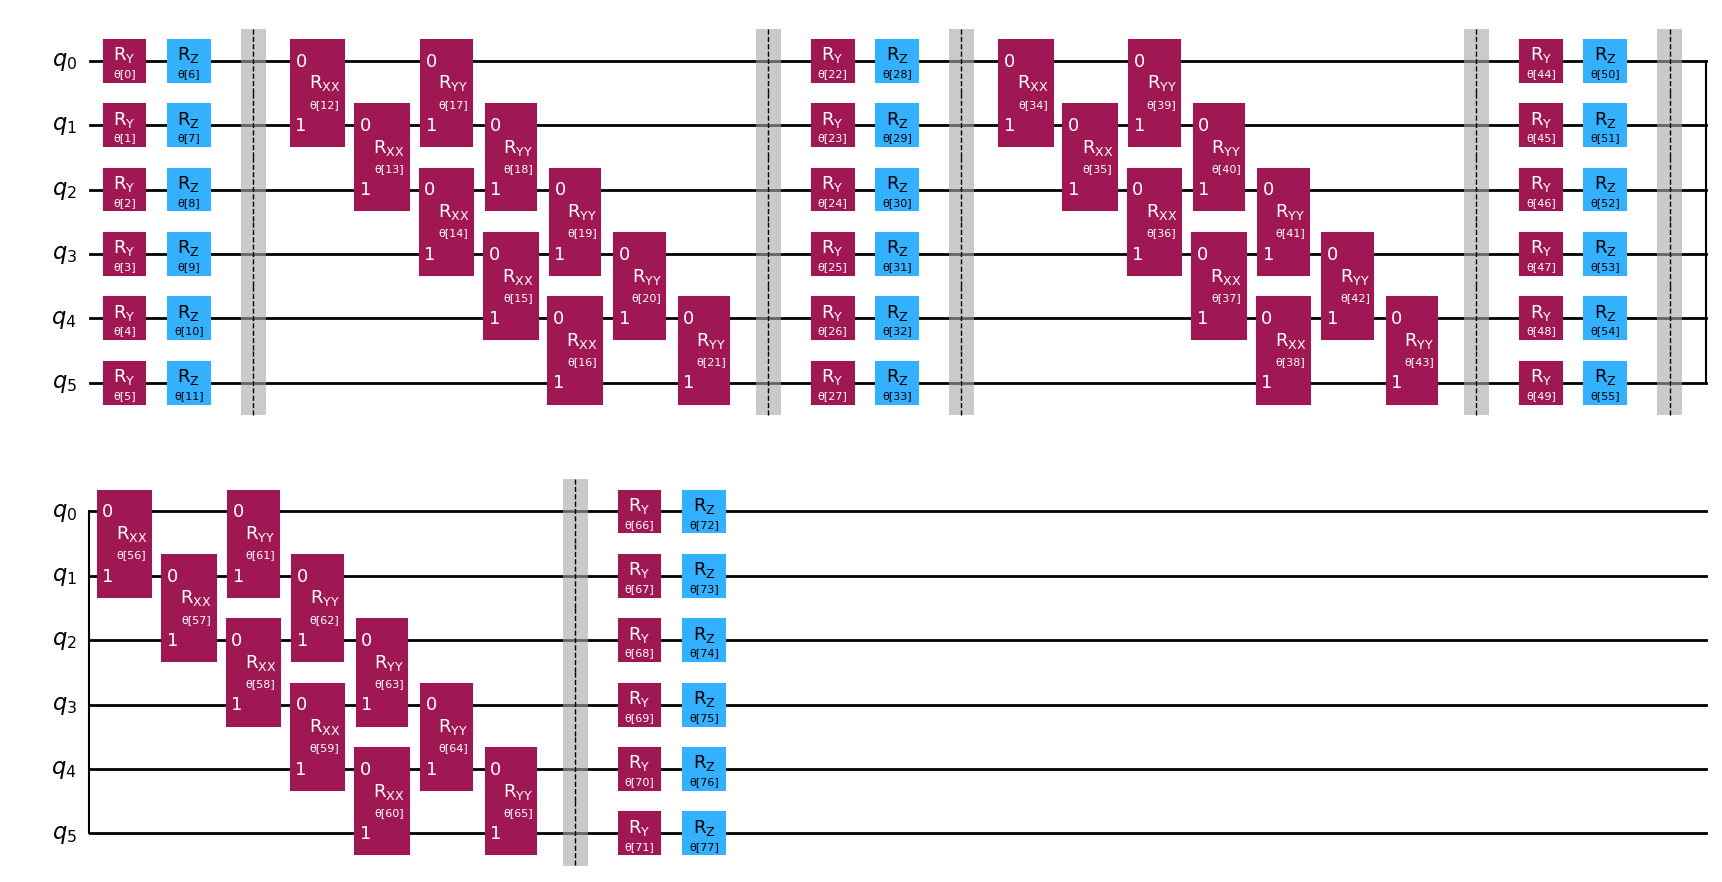

In [ ]:
# In NLocal, the circuit blocks can have arbitrary sizes (smaller equal to the number of qubits in the circuit),
# while in TwoLocal, the rotation layers are single qubit gates applied on all qubits
#  and the entanglement layer uses two-qubit gates

from qiskit.circuit import QuantumCircuit
from qiskit.circuit.library.n_local import n_local

nlocal = n_local(6, rotation_blocks=['ry', 'rz'], entanglement_blocks=['rxx', 'ryy'], entanglement='linear', insert_barriers=True)
nlocal.draw('mpl')